### The objective of this notebook is to create publication-ready forecast charts for the project write-up

In [1]:
# Importing the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
# Defining a custom color palette
TEAL = "#0F4C5C" # Primary colour
TEAL_LIGHT = "#5A8A99"

ACCENT = "#C04000" # For highlights and / or forecasts
GREY = "#4A4A4A" # For actuals and / or neutral elements
LIGHT_GREY = "#B0B0B0"

# Custom color palette for multi-series plots
custom_palette = ["#0F4C5C",
                  "#C04000",
                  "#2E5A2E",
                  "#7B2D26",
                  "#3D5A80",
                  "#8B6F47",
                  "#5C4B51",
                  "#A4B494",
                  "#9B5DE5",
                  "#4A4A4A"] 
sns.set_theme(style = 'whitegrid', context = 'notebook',palette=custom_palette)

plt.rcParams['figure.figsize'] = (12,5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.prop_cycle'] = plt.cycler(color = custom_palette)

In [3]:
# Loading the output files
actuals = pd.read_csv('../data/processed/hierarchy_ready.csv')
actuals['ds'] = pd.to_datetime(actuals['ds'])
base_forecasts = pd.read_csv('../outputs/base_forecasts.csv')
base_forecasts['ds'] = pd.to_datetime(base_forecasts['ds'])
reconciled_forecasts = pd.read_csv('../outputs/reconciled_forecasts.csv')
reconciled_forecasts['ds'] = pd.to_datetime(reconciled_forecasts['ds'])
lightgbm_forecasts = pd.read_csv('../outputs/lightgbm_forecasts.csv')
lightgbm_forecasts['ds'] = pd.to_datetime(lightgbm_forecasts['ds'])
lightgbm_reconciled = pd.read_csv('../outputs/lightgbm_reconciled.csv')
lightgbm_reconciled['ds'] = pd.to_datetime(lightgbm_reconciled['ds'])

In [4]:
to_drop = {
    'TOTAL/MUMBAI/MUMBAI-RAJKOT',
    'TOTAL/DELHI/DELHI-RAJKOT',
    'TOTAL/DEHRA DUN/DEHRA DUN-DELHI',
    'TOTAL/DEHRA DUN'
}

actuals = actuals[~actuals['unique_id'].isin(to_drop)].copy()

In [5]:
print('actuals: ',actuals.shape)
print('base_forecasts: ',base_forecasts.shape)
print('reconciled_forecasts: ',reconciled_forecasts.shape)
print('lightgbm_forecasts: ',lightgbm_forecasts.shape)
print('lightgbm_reconciled: ',lightgbm_reconciled.shape)

actuals:  (26677, 3)
base_forecasts:  (2736, 6)
reconciled_forecasts:  (2736, 14)
lightgbm_forecasts:  (2736, 3)
lightgbm_reconciled:  (2736, 5)


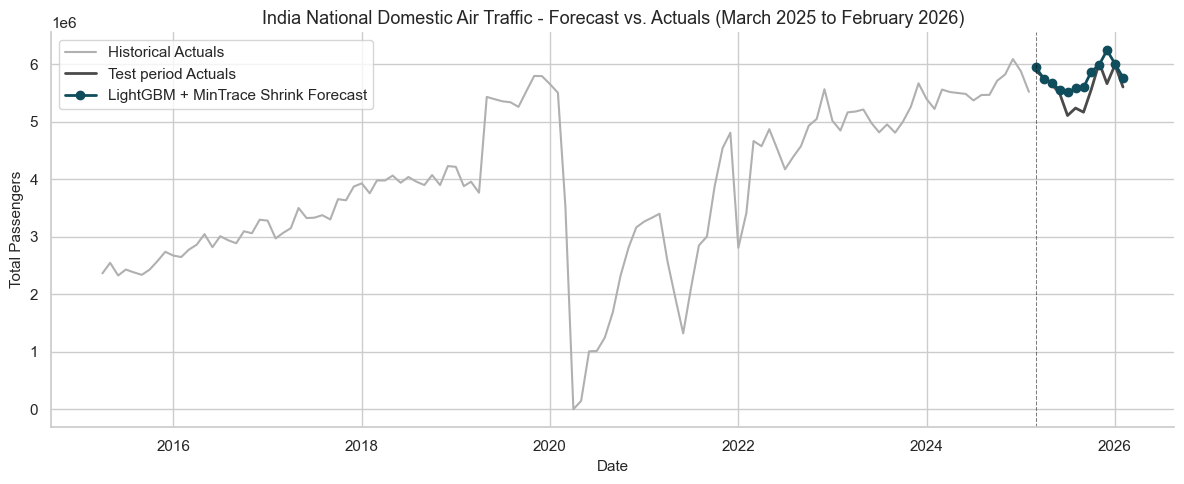

In [11]:
total_actuals = actuals[actuals['unique_id'] == 'TOTAL'].sort_values('ds')
total_forecast = lightgbm_reconciled[lightgbm_reconciled['unique_id'] == 'TOTAL'].sort_values('ds')

split_date = pd.Timestamp('2025-03-01')

train_actuals = total_actuals[total_actuals['ds'] < split_date]
test_actuals = total_actuals[total_actuals['ds'] >= split_date]

fig, ax = plt.subplots(figsize = (12,5))
ax.plot(train_actuals['ds'],train_actuals['y'],color = LIGHT_GREY, lw = 1.5, label = 'Historical Actuals')
ax.plot(test_actuals['ds'],test_actuals['y'], color = GREY, lw = 2, label = 'Test period Actuals')
ax.plot(total_forecast['ds'], total_forecast['LightGBM/MinTrace_method-mint_shrink'],color = TEAL, lw = 2, marker = 'o', label = 'LightGBM + MinTrace Shrink Forecast')
ax.axvline(split_date, color = 'black', lw = 0.75, ls = '--', alpha = 0.5)

ax.set_title('India National Domestic Air Traffic - Forecast vs. Actuals (March 2025 to February 2026)')
ax.set_xlabel('Date')
ax.set_ylabel('Total Passengers')
ax.legend(loc = 'upper left')
plt.tight_layout()
plt.savefig('../outputs/chart_national_forecast.png', dpi = 150, bbox_inches = 'tight')
plt.show()


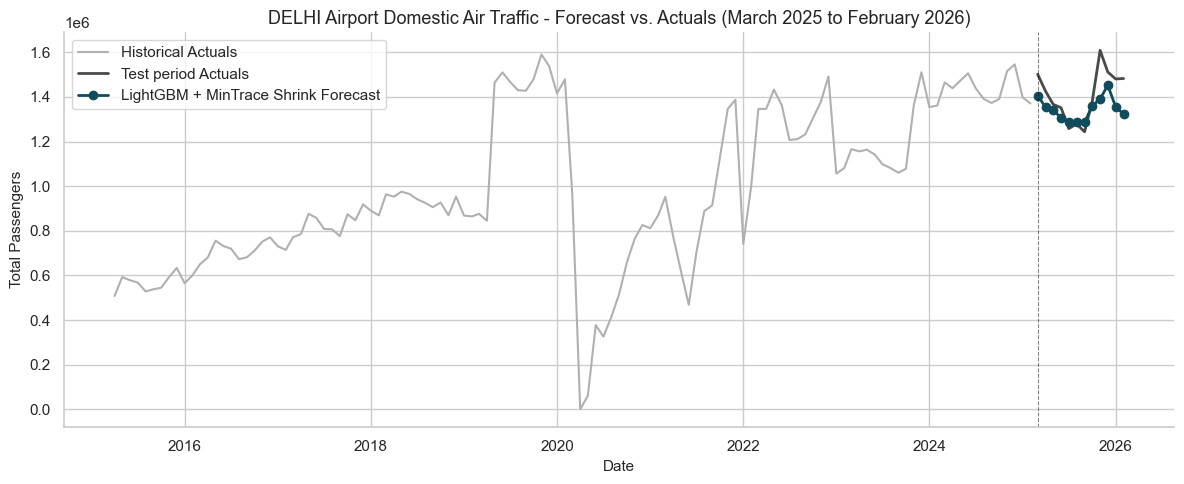

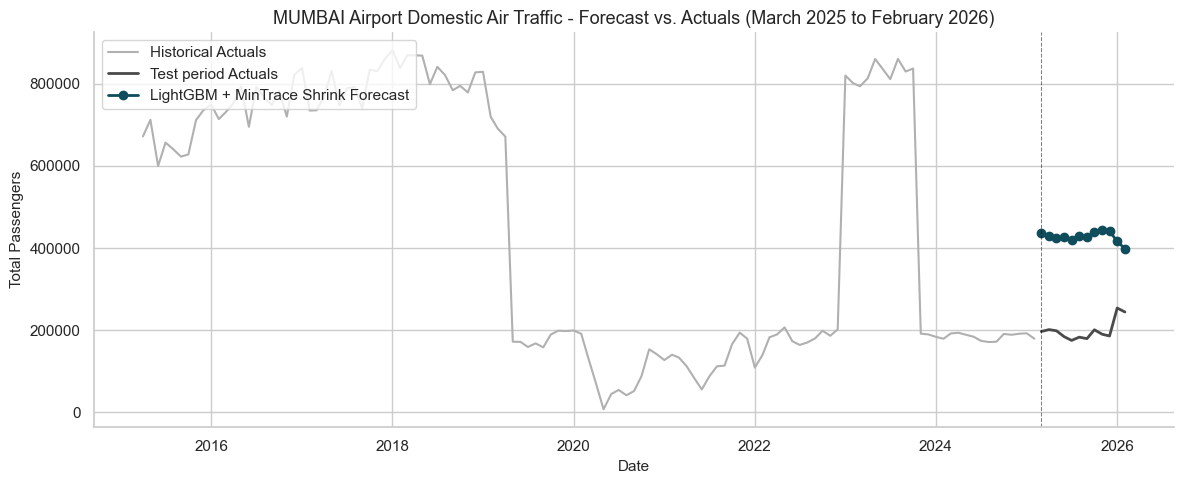

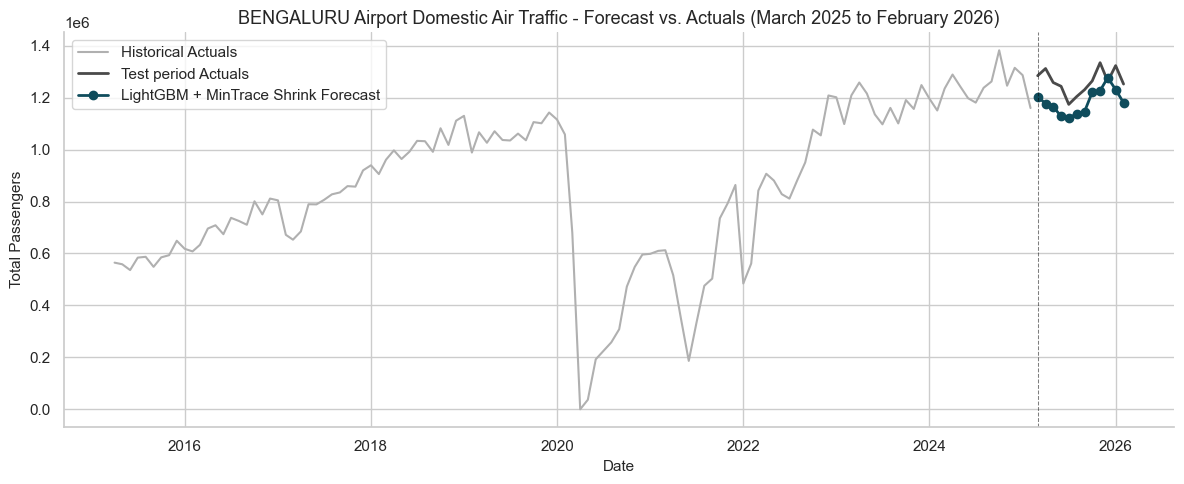

In [18]:
airports = ['DELHI', 'MUMBAI', 'BENGALURU']
for airport in airports:
    total_actuals = actuals[actuals['unique_id'] == f'TOTAL/{airport}'].sort_values('ds')
    total_forecast = lightgbm_reconciled[lightgbm_reconciled['unique_id'] == f'TOTAL/{airport}'].sort_values('ds')

    split_date = pd.Timestamp('2025-03-01')

    train_actuals = total_actuals[total_actuals['ds'] < split_date]
    test_actuals = total_actuals[total_actuals['ds'] >= split_date]

    fig, ax = plt.subplots(figsize = (12,5))
    ax.plot(train_actuals['ds'],train_actuals['y'],color = LIGHT_GREY, lw = 1.5, label = 'Historical Actuals')
    ax.plot(test_actuals['ds'],test_actuals['y'], color = GREY, lw = 2, label = 'Test period Actuals')
    ax.plot(total_forecast['ds'], total_forecast['LightGBM/MinTrace_method-mint_shrink'],color = TEAL, lw = 2, marker = 'o', label = 'LightGBM + MinTrace Shrink Forecast')
    ax.axvline(split_date, color = 'black', lw = 0.75, ls = '--', alpha = 0.5)

    ax.set_title(f'{airport} Airport Domestic Air Traffic - Forecast vs. Actuals (March 2025 to February 2026)')
    ax.set_xlabel('Date')
    ax.set_ylabel('Total Passengers')
    ax.legend(loc = 'upper left')
    plt.tight_layout()
    plt.savefig(f'../outputs/chart_{airport}_airport_forecast.png', dpi = 150, bbox_inches = 'tight')
    plt.show()


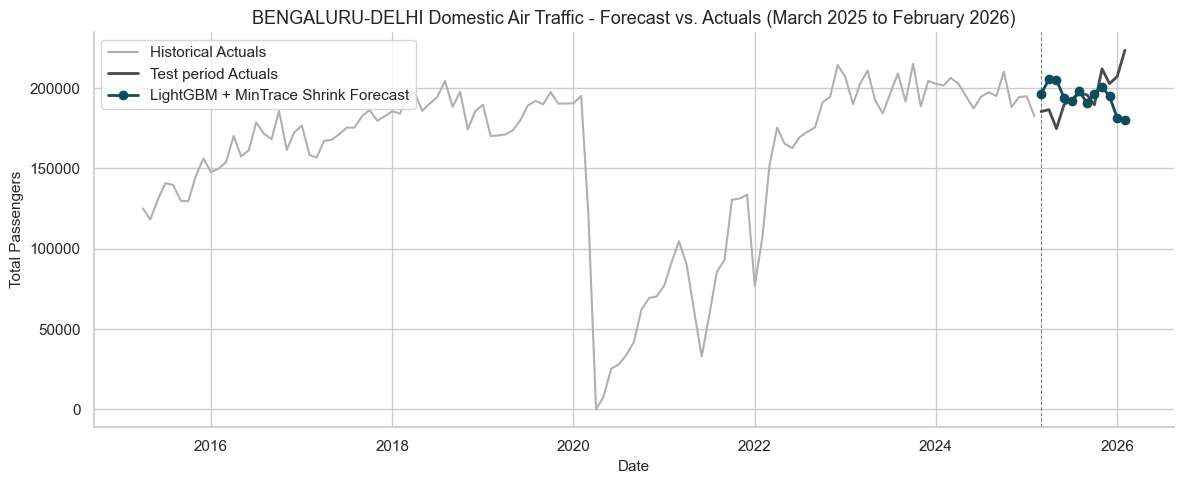

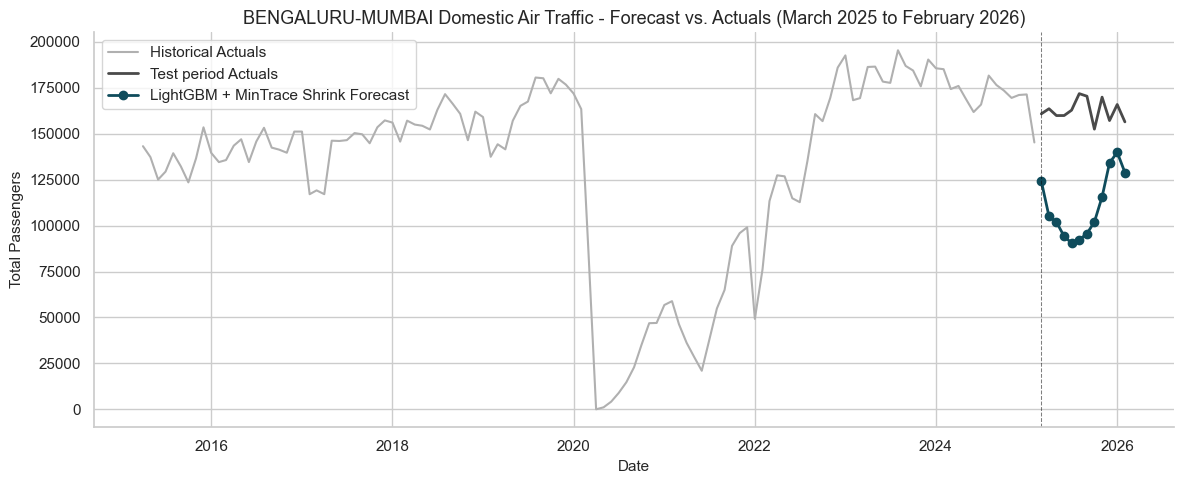

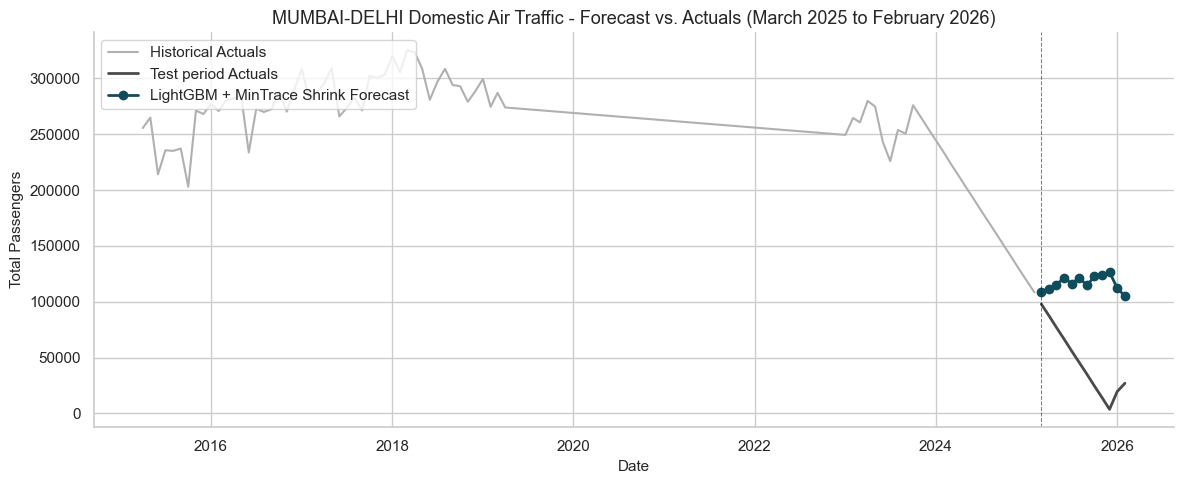

In [19]:
top_3_routes = ['BENGALURU-DELHI', 'BENGALURU-MUMBAI', 'MUMBAI-DELHI']
for route in top_3_routes:
    origin = route.split('-')[0]
    total_actuals = actuals[actuals['unique_id'] == f'TOTAL/{origin}/{route}'].sort_values('ds')
    total_forecast = lightgbm_reconciled[lightgbm_reconciled['unique_id'] == f'TOTAL/{origin}/{route}'].sort_values('ds')

    split_date = pd.Timestamp('2025-03-01')

    train_actuals = total_actuals[total_actuals['ds'] < split_date]
    test_actuals = total_actuals[total_actuals['ds'] >= split_date]

    fig, ax = plt.subplots(figsize = (12,5))
    ax.plot(train_actuals['ds'],train_actuals['y'],color = LIGHT_GREY, lw = 1.5, label = 'Historical Actuals')
    ax.plot(test_actuals['ds'],test_actuals['y'], color = GREY, lw = 2, label = 'Test period Actuals')
    ax.plot(total_forecast['ds'], total_forecast['LightGBM/MinTrace_method-mint_shrink'],color = TEAL, lw = 2, marker = 'o', label = 'LightGBM + MinTrace Shrink Forecast')
    ax.axvline(split_date, color = 'black', lw = 0.75, ls = '--', alpha = 0.5)

    ax.set_title(f'{route} Domestic Air Traffic - Forecast vs. Actuals (March 2025 to February 2026)')
    ax.set_xlabel('Date')
    ax.set_ylabel('Total Passengers')
    ax.legend(loc = 'upper left')
    plt.tight_layout()
    plt.savefig(f'../outputs/chart_{route}_route_forecast.png', dpi = 150, bbox_inches = 'tight')
    plt.show()
